In [15]:
# First time run karein - phir comment kar dein
!pip install requests beautifulsoup4 pandas

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from datetime import datetime

print("=" * 60)
print("All Libraries Imported Successfully")
print("=" * 60)

All Libraries Imported Successfully


In [2]:
def log_progress(message):

    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    with open("pakwheels_log.txt", "a") as file:
        file.write(f"{timestamp} : {message}\n")

    print(message)

log_progress("Logging Function Created")

Logging Function Created


In [4]:
def scrape_pakwheels(pages=50):

    all_cars = []

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    for page in range(1, pages + 1):

        log_progress(f"Scraping Page {page}")

        url = f"https://www.pakwheels.com/used-cars/search/-/?page={page}"

        try:

            response = requests.get(url, headers=headers)

            soup = BeautifulSoup(response.text, "html.parser")

            listings = soup.find_all("li", class_="classified-listing")

            log_progress(f"Listings Found: {len(listings)}")

            for listing in listings:

                try:

                    car_data = {
                        "Name": "N/A",
                        "Price": "N/A",
                        "Year": "N/A",
                        "Mileage": "N/A",
                        "City": "N/A",
                        "Fuel_Type": "N/A",
                        "Transmission": "N/A",
                        "Rating": "N/A"
                    }

                    # Name
                    try:
                        car_data["Name"] = listing.find("h3").text.strip()
                    except:
                        pass

                    # Price
                    try:
                        car_data["Price"] = listing.find(
                            "div",
                            class_="price-details"
                        ).text.strip()
                    except:
                        pass

                    # Details
                    details = listing.find_all("li")

                    for detail in details:

                        text = detail.text.strip().lower()

                        # Year
                        if text.isdigit() and len(text) == 4:
                            car_data["Year"] = text

                        # Mileage
                        elif "km" in text:
                            car_data["Mileage"] = text

                        # Fuel
                        elif any(f in text for f in [
                            "petrol",
                            "diesel",
                            "hybrid",
                            "electric"
                        ]):
                            car_data["Fuel_Type"] = text

                        # Transmission
                        elif any(t in text for t in [
                            "manual",
                            "automatic"
                        ]):
                            car_data["Transmission"] = text

                    # City
                    try:
                        city = listing.find(
                            "ul",
                            class_="list-unstyled search-vehicle-info-2 fs13"
                        ).find_all("li")[-1].text.strip()

                        car_data["City"] = city

                    except:
                        pass

                    if car_data["Name"] != "N/A":
                        all_cars.append(car_data)

                except:
                    continue

            log_progress(f"Total Cars Collected: {len(all_cars)}")

            time.sleep(2)

        except Exception as e:

            log_progress(f"Error on Page {page}: {e}")

    return all_cars

In [5]:
print("=" * 70)
print("PakWheels Data Extraction Started")
print("=" * 70)

cars_data = scrape_pakwheels(pages=50)

print("\n" + "=" * 70)
print("SCRAPING COMPLETED")
print(f"Total Cars Scraped: {len(cars_data)}")
print("=" * 70)

PakWheels Data Extraction Started
Scraping Page 1
Listings Found: 30
Total Cars Collected: 30
Scraping Page 2
Listings Found: 37
Total Cars Collected: 67
Scraping Page 3
Listings Found: 37
Total Cars Collected: 104
Scraping Page 4
Listings Found: 37
Total Cars Collected: 141
Scraping Page 5
Listings Found: 37
Total Cars Collected: 178
Scraping Page 6
Listings Found: 37
Total Cars Collected: 215
Scraping Page 7
Listings Found: 37
Total Cars Collected: 252
Scraping Page 8
Listings Found: 37
Total Cars Collected: 289
Scraping Page 9
Listings Found: 37
Total Cars Collected: 326
Scraping Page 10
Listings Found: 37
Total Cars Collected: 363
Scraping Page 11
Listings Found: 37
Total Cars Collected: 400
Scraping Page 12
Listings Found: 37
Total Cars Collected: 437
Scraping Page 13
Listings Found: 37
Total Cars Collected: 474
Scraping Page 14
Listings Found: 37
Total Cars Collected: 511
Scraping Page 15
Listings Found: 37
Total Cars Collected: 548
Scraping Page 16
Listings Found: 37
Total Cars 

In [9]:
df = pd.DataFrame(cars_data)

required_columns = [
    'Name',
    'Price',
    'Year',
    'Mileage',
    'City',
    'Fuel_Type',
    'Transmission',
    'Rating'
]

df = df[required_columns]

print(df.head())

print("\nDataset Shape:", df.shape)

                                                Name           Price  Year  \
0                   Jaecoo J5  2026 Premium for Sale   PKR 84.5 lacs  2026   
1  Toyota Corolla  2012 Altis SR Cruisetronic 1.6...     PKR 38 lacs  2012   
2                         Nissan Kix  2011  for Sale  PKR 24.85 lacs  2011   
3    Honda Civic  2017 Oriel 1.8 i-VTEC CVT for Sale  PKR 52.85 lacs  2017   
4        Mercedes Benz EQC  2020 400 4MATIC for Sale  PKR 1.45 crore  2020   

      Mileage       City Fuel_Type Transmission Rating  
0        1 km  Automatic    hybrid    automatic    N/A  
1  277,000 km  Automatic    petrol    automatic    N/A  
2   98,000 km  Automatic    petrol    automatic    N/A  
3   94,000 km  Automatic    petrol    automatic    N/A  
4   69,064 km  Automatic  electric    automatic    N/A  

Dataset Shape: (1843, 8)


In [10]:
print("=" * 60)
print("DATA CLEANING")
print("=" * 60)

print("Before Cleaning:", len(df))

df = df.drop_duplicates()

df = df.replace("N/A", np.nan)

df = df.dropna(subset=["Name"])

print("After Cleaning:", len(df))

print("\n Cleaning Completed")

DATA CLEANING
Before Cleaning: 1843
After Cleaning: 1466

 Cleaning Completed


C:\Users\HAFIZ ATIQ\AppData\Local\Temp\ipykernel_2728\3266275363.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("N/A", np.nan)


In [11]:
print("=" * 60)
print("CLEAN DATA PREVIEW")
print("=" * 60)

display(df.head(10))

CLEAN DATA PREVIEW


,Name,Price,Year,Mileage,City,Fuel_Type,Transmission,Rating
0,Jaecoo J5 2026 Premium for Sale,PKR 84.5 lacs,2026,1 km,Automatic,hybrid,automatic,NaN
1,Toyota Corolla 2012 Altis SR Cruisetronic 1.6...,PKR 38 lacs,2012,"277,000 km",Automatic,petrol,automatic,NaN
2,Nissan Kix 2011 for Sale,PKR 24.85 lacs,2011,"98,000 km",Automatic,petrol,automatic,NaN
3,Honda Civic 2017 Oriel 1.8 i-VTEC CVT for Sale,PKR 52.85 lacs,2017,"94,000 km",Automatic,petrol,automatic,NaN
4,Mercedes Benz EQC 2020 400 4MATIC for Sale,PKR 1.45 crore,2020,"69,064 km",Automatic,electric,automatic,NaN
5,Honda Vezel 2014 X Honda Sensing for Sale,PKR 39.75 lacs,2014,"71,000 km",Automatic,hybrid,automatic,NaN
6,Toyota Prado 2017 TX 2.7 for Sale,PKR 2.05 crore,2017,"95,856 km",Automatic,petrol,automatic,NaN
7,Suzuki Wagon R 2021 VXL for Sale,PKR 31 lacs,2021,"42,000 km",Manual,petrol,manual,NaN
8,Suzuki Cultus 2022 VXR for Sale,PKR 32.5 lacs,2022,"75,000 km",Manual,petrol,manual,NaN
9,Toyota Prius 2014 G Touring Selection 1.8 for...,PKR 49.5 lacs,2014,"88,500 km",Automatic,hybrid,automatic,NaN


In [12]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f"pakwheels_1000cars_{timestamp}.csv"

df.to_csv(filename, index=False, encoding="utf-8-sig")

log_progress(f" CSV Saved: {filename}")

print("=" * 60)
print(" CSV FILE SAVED")
print("=" * 60)

print("Filename:", filename)
print("Location:", os.getcwd())

 CSV Saved: pakwheels_1000cars_20260515_001211.csv
 CSV FILE SAVED
Filename: pakwheels_1000cars_20260515_001211.csv
Location: D:\Cloud Data Engineering\Pak Wheels Data Scraping


In [13]:
df_verify = pd.read_csv(filename)

print(df_verify.head())

print("\nCSV Shape:", df_verify.shape)

                                                Name           Price  Year  \
0                   Jaecoo J5  2026 Premium for Sale   PKR 84.5 lacs  2026   
1  Toyota Corolla  2012 Altis SR Cruisetronic 1.6...     PKR 38 lacs  2012   
2                         Nissan Kix  2011  for Sale  PKR 24.85 lacs  2011   
3    Honda Civic  2017 Oriel 1.8 i-VTEC CVT for Sale  PKR 52.85 lacs  2017   
4        Mercedes Benz EQC  2020 400 4MATIC for Sale  PKR 1.45 crore  2020   

      Mileage       City Fuel_Type Transmission  Rating  
0        1 km  Automatic    hybrid    automatic     NaN  
1  277,000 km  Automatic    petrol    automatic     NaN  
2   98,000 km  Automatic    petrol    automatic     NaN  
3   94,000 km  Automatic    petrol    automatic     NaN  
4   69,064 km  Automatic  electric    automatic     NaN  

CSV Shape: (1466, 8)


In [14]:
print(df['City'].value_counts().head(10))

City
Automatic    971
Manual       460
4 Grade       12
4.5 Grade      6
3.5 Grade      5
*** Grade      4
R Grade        4
5 Grade        2
6 Grade        1
RA Grade       1
Name: count, dtype: int64


In [15]:
print(df['Fuel_Type'].value_counts())

Fuel_Type
petrol      1284
hybrid        88
diesel        63
electric      13
Name: count, dtype: int64


In [16]:
print(df['Transmission'].value_counts())

Transmission
automatic    1005
manual        461
Name: count, dtype: int64


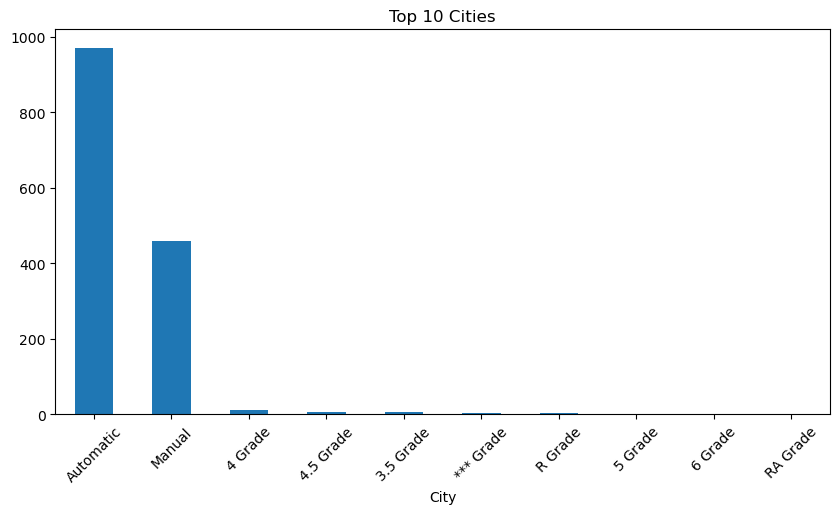

In [17]:
plt.figure(figsize=(10,5))

df['City'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Cities")

plt.xticks(rotation=45)

plt.show()

In [18]:
with open("pakwheels_log.txt", "r") as file:
    logs = file.read()

print(logs)

2026-05-15 00:00:10 : Logging Function Created
2026-05-15 00:04:12 : Scraping Page 1
2026-05-15 00:04:14 : Listings Found: 30
2026-05-15 00:04:14 : Total Cars Collected: 30
2026-05-15 00:04:16 : Scraping Page 2
2026-05-15 00:04:19 : Listings Found: 37
2026-05-15 00:04:19 : Total Cars Collected: 67
2026-05-15 00:04:21 : Scraping Page 3
2026-05-15 00:04:23 : Listings Found: 37
2026-05-15 00:04:23 : Total Cars Collected: 104
2026-05-15 00:04:25 : Scraping Page 4
2026-05-15 00:04:27 : Listings Found: 37
2026-05-15 00:04:27 : Total Cars Collected: 141
2026-05-15 00:04:29 : Scraping Page 5
2026-05-15 00:04:33 : Listings Found: 37
2026-05-15 00:04:33 : Total Cars Collected: 178
2026-05-15 00:04:35 : Scraping Page 6
2026-05-15 00:04:45 : Listings Found: 37
2026-05-15 00:04:46 : Total Cars Collected: 215
2026-05-15 00:04:48 : Scraping Page 7
2026-05-15 00:04:51 : Listings Found: 37
2026-05-15 00:04:51 : Total Cars Collected: 252
2026-05-15 00:04:53 : Scraping Page 8
2026-05-15 00:04:55 : Listin